In [ ]:
from pathlib import Path
import sys

_REPO_ROOT = Path("..").resolve()
_SRC = _REPO_ROOT / "src"
if _SRC.is_dir() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import matplotlib.pyplot as plt

from critical_minerals_aster.config import load_site_config
from critical_minerals_aster.paths import site_paths_for
from critical_minerals_aster.pipeline import resolve_granule_id
from critical_minerals_aster.spectral import alteration_ratios, load_tir_bands_10_14

site = load_site_config(_REPO_ROOT / "sites" / "mcdermitt.yaml")
paths = site_paths_for(site, _REPO_ROOT)
granule_id = resolve_granule_id(site, paths)

b10, b11, b12, b13, b14, profile, transform, crs = load_tir_bands_10_14(
    paths.aster_dir, granule_id
)
silica, carbonate, mafic = alteration_ratios(b12, b13, b14)

print("Ready")
print(f"CRS: {crs}")
print(f"Transform: {transform}")

Ready
CRS: EPSG:32611
Transform: | 90.00, 0.00, 412920.00|
| 0.00,-90.00, 4698810.00|
| 0.00, 0.00, 1.00|


In [ ]:
from critical_minerals_aster.classification import classify_percentiles, combined_score

cp = site.classification
assert cp is not None
silica_cls, s_lo, s_hi = classify_percentiles(silica, cp.low_pct, cp.high_pct)
carbonate_cls, c_lo, c_hi = classify_percentiles(carbonate, cp.low_pct, cp.high_pct)
mafic_cls, m_lo, m_hi = classify_percentiles(mafic, cp.low_pct, cp.high_pct)

combined = combined_score(silica_cls, carbonate_cls, mafic_cls)

print(f"Silica    thresholds: moderate={s_lo:.4f}, strong={s_hi:.4f}")
print(f"Carbonate thresholds: moderate={c_lo:.4f}, strong={c_hi:.4f}")
print(f"Mafic     thresholds: moderate={m_lo:.4f}, strong={m_hi:.4f}")
print(f"\nCombined score distribution:")
for v in range(7):
    count = np.sum(combined == v)
    pct = count / combined.size * 100
    print(f"  score {v}: {count:6d} pixels ({pct:.1f}%)")

Silica    thresholds: moderate=0.9729, strong=0.9762
Carbonate thresholds: moderate=1.1435, strong=1.1519
Mafic     thresholds: moderate=0.8802, strong=0.8844

Combined score distribution:
  score 0: 466281 pixels (57.4%)
  score 1: 182676 pixels (22.5%)
  score 2: 108510 pixels (13.4%)
  score 3:  30403 pixels (3.7%)
  score 4:  24086 pixels (3.0%)
  score 5:      0 pixels (0.0%)
  score 6:      0 pixels (0.0%)


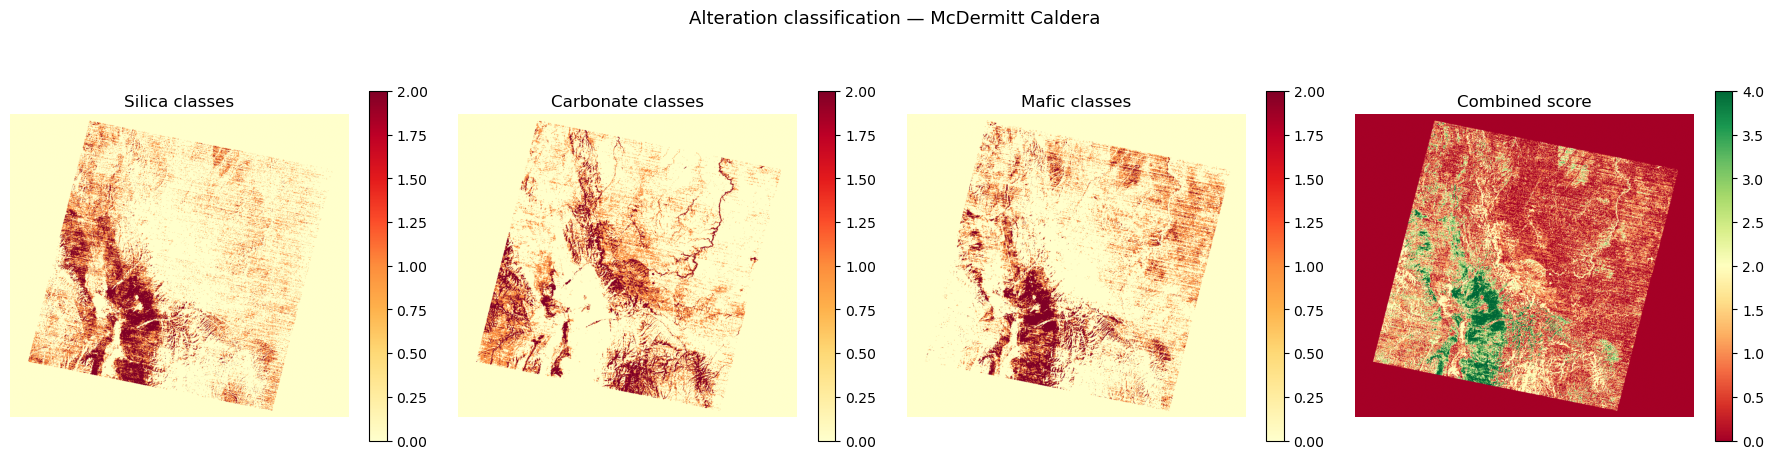


Vectorized 8587 strong anomaly zones
Total anomaly area: 441.4 km²
Largest zone: 185.9 km²


In [ ]:
from critical_minerals_aster.classification import vectorize_strong_zones

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

cmaps = ['YlOrRd', 'YlOrRd', 'YlOrRd', 'RdYlGn']
titles = ['Silica classes', 'Carbonate classes', 'Mafic classes', 'Combined score']
arrays = [silica_cls, carbonate_cls, mafic_cls, combined]

for ax, arr, title, cmap in zip(axes, arrays, titles, cmaps):
    im = ax.imshow(arr, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f'Alteration classification — {site.name}', fontsize=13)
plt.tight_layout()
plt.savefig(paths.figures_dir / '02_classification.png', dpi=150, bbox_inches='tight')
plt.show()

zones = vectorize_strong_zones(
    combined,
    transform,
    crs,
    min_score=cp.strong_score_min,
)

print(f"\nVectorized {len(zones)} strong anomaly zones")
print(f"Total anomaly area: {zones['area_km2'].sum():.1f} km²")
print(f"Largest zone: {zones['area_km2'].max():.1f} km²")

In [ ]:
paths.vectors_dir.mkdir(parents=True, exist_ok=True)
out = paths.vectors_dir / "strong_anomaly_zones.geojson"
zones.to_file(out, driver="GeoJSON")
print(f"Saved {len(zones)} zones to {out}")

# Quick summary stats
zones_sorted = zones.sort_values('area_km2', ascending=False)
print(f"\nTop 10 largest anomaly zones:")
print(zones_sorted[['area_km2']].head(10).to_string())

Saved 8587 zones to data/vectors/strong_anomaly_zones.geojson

Top 10 largest anomaly zones:
      area_km2
8239  185.8626
8041   16.6212
3182    5.8887
4190    5.5566
4359    5.4432
5928    4.4307
2574    3.0861
2027    3.0537
6643    3.0051
2841    2.5353
